## **[1] Framing the Problem**

**1. Problem and Solution**
  - *Problems:* Poor service; Billing issues; Competitor offers; Lack of value; Poor experience.
  - *Solutions:* Identify at-risk customers; Service improvement; Improve onboarding experience to build loyalty from start; Flexible Payments; Strategic bundling; Personalized offers; Engage with customers (support, response,...)
    - **Churn is driven by early-tenure customers on month-to-month contracts with high monthly charges and low service stickiness.**

**2. Target Customers**
  - Active customers at risk of churn in the next billing cycle / next 30–90 days

**3. Identify ML model Type (Supervised/Unsupervised)**
  - ***"Supervised Machine Learning"***
     - LABELED DATA
     - Identify label: The "TARGET" variable- 'Churn'
     - Check values: 'Yes/No'
     - Target is categorical -> **Classification problem** & there are 2 outcomes (yes/no) -> **Binary Classification Problem**

**4. Deployment Model (Online/Batch)**
  - **"Batch"** -> model runs on a schedule to score all customers at once and save results to a database

**5. Data Source**
  - Kaggle [Telco Customer Churn -- Focused Customer Retention; IBM's Sample Dataset]

## **[2] Data Collection**

**1. Problem and Solution**
  - Source: CSV File from Kaggle -> Telco Customer Churn:- Focused Customer Retention; IBM's Sample Dataset

## **[3] Data Preprocessing**
-

## **[4] Exploratory Data Analysis**


### **1. Analyze Data >>>**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.sample(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
872,1764-VUUMT,Male,0,No,Yes,66,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),19.95,1269.1,No
1895,3638-VBZTA,Male,0,No,Yes,68,Yes,Yes,DSL,Yes,...,No,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),86.50,5882.75,No
5120,8563-IIOXK,Male,0,Yes,Yes,7,Yes,No,DSL,Yes,...,No,No,No,No,One year,Yes,Electronic check,49.75,331.3,Yes
2783,4760-THGOT,Female,0,Yes,No,43,Yes,Yes,Fiber optic,Yes,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,94.10,4107.3,No
6092,4024-CSNBY,Female,0,Yes,No,72,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,No,No,Two year,Yes,Bank transfer (automatic),94.25,6849.75,No


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
# convert datatype of 'TotalCharges' into integer

df = pd.DataFrame(data=df)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [10]:
df.corr(numeric_only=True)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.016567,0.220173,0.102411
tenure,0.016567,1.000000,0.247900,0.825880
MonthlyCharges,0.220173,0.247900,1.000000,0.651065
TotalCharges,0.102411,0.825880,0.651065,1.000000


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [12]:
# Look for all the "NaN" values in TotalCharges
print(df[df['TotalCharges'].isna()])

      customerID  gender  SeniorCitizen Partner Dependents  tenure  \
488   4472-LVYGI  Female              0     Yes        Yes       0   
753   3115-CZMZD    Male              0      No        Yes       0   
936   5709-LVOEQ  Female              0     Yes        Yes       0   
1082  4367-NUYAO    Male              0     Yes        Yes       0   
1340  1371-DWPAZ  Female              0     Yes        Yes       0   
3331  7644-OMVMY    Male              0     Yes        Yes       0   
3826  3213-VVOLG    Male              0     Yes        Yes       0   
4380  2520-SGTTA  Female              0     Yes        Yes       0   
5218  2923-ARZLG    Male              0     Yes        Yes       0   
6670  4075-WKNIU  Female              0     Yes        Yes       0   
6754  2775-SEFEE    Male              0      No        Yes       0   

     PhoneService     MultipleLines InternetService       OnlineSecurity  ...  \
488            No  No phone service             DSL                  Yes  ... 

In [13]:
# 11 customers (~0.15%) have tenure = 0, making TotalCharges undefined. 
# These represent newly onboarded customers with no billing history and were removed to avoid noise.
    
df = df.dropna(subset=['TotalCharges'])

# Optional but explicit
# df = df[~((df['tenure'] == 0) & (df['TotalCharges'] == 0))]

print(df[df['tenure'] == 0].shape[0])

0


In [14]:
df.drop(columns=['customerID'], inplace=True)

### **2. Visualizations >>>**

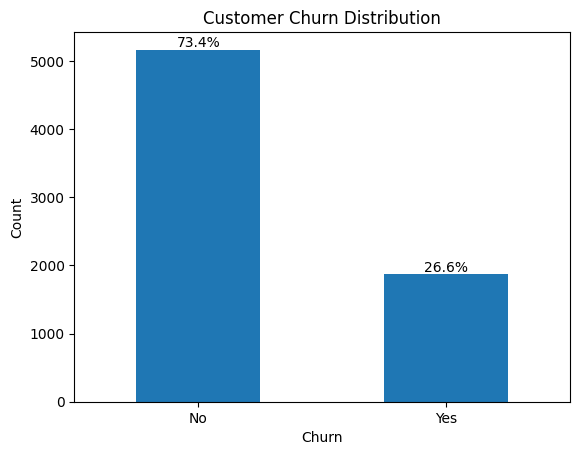

In [15]:
# 2. Calculate percentages and prepare data
churn_counts = df['Churn'].value_counts()
total = len(df)

# Create a DataFrame for plotting to ensure alignment
plot_df = pd.DataFrame({
    'Count': churn_counts,
    'Percentage': (churn_counts / total) * 100
})

# 3. Create the bar chart
ax = plot_df['Count'].plot.bar(rot=0, legend=False)

# 4. Add percentage labels
for i, p in enumerate(ax.patches):
    # Get the percentage value that corresponds to this bar
    percentage = plot_df['Percentage'].iloc[i]
    # Format the label as a percentage string
    label = f'{percentage:.1f}%'
    # Add the label above the bar
    ax.annotate(label, 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom')

plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

#### >>> **26.5%** of customers have churned, indicating a material retention risk.

### **3. Univariate Analysis (One variable at a time) >>>**

#### (i) Categorical

<Axes: xlabel='Contract'>

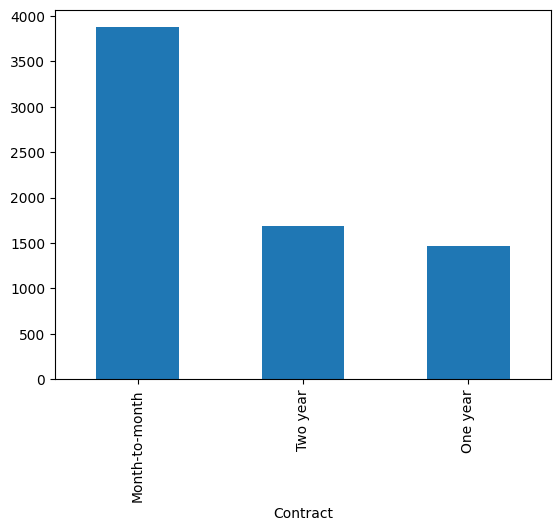

In [16]:
df['Contract'].value_counts().plot(kind='bar')

**Conclusion**

    The customer base is heavily skewed towards 'month-to-month' contract. 

**Business Phrasing:** *A large number of customers are not engaged into long-term contracts, which might increase churn risk. The customers might leave anytime.*

<Axes: xlabel='PaymentMethod'>

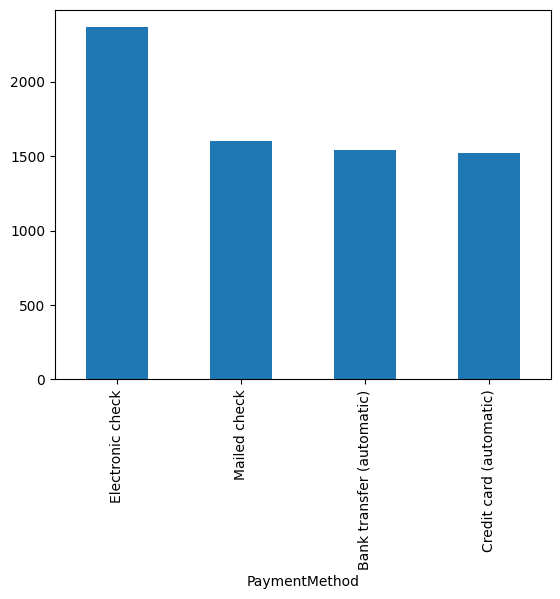

In [17]:
df['PaymentMethod'].value_counts().plot(kind='bar')

**Conclusion**

    The 'Electronic check' is commonly used payment method as compared to automated methods.

**Business Phrasing:** *A significant group of customers prefer manual payment over automated payment method engagement/adoption.*

<Axes: xlabel='InternetService'>

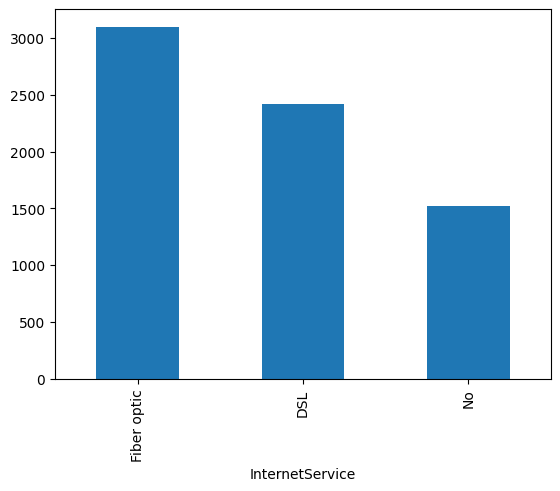

In [18]:
df['InternetService'].value_counts().plot(kind='bar')

**Conclusion**

    Most customers subscribe to internet service, where 'fibre-optic' is leading service type.

**Business Phrasing:** *The customers are internet-driven. It makes the service quality and pricing crucial business lever.*

#### (ii) Numerical

<Axes: xlabel='SeniorCitizen'>

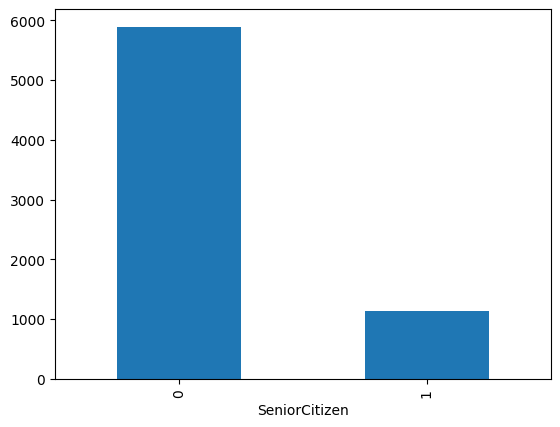

In [19]:
df['SeniorCitizen'].value_counts().plot(kind='bar')

**Conclusion**

    Non-senior customer base is larger and dominating senior citizen customer base.

*Seniors are a minority.*

<Axes: xlabel='tenure', ylabel='Percent'>

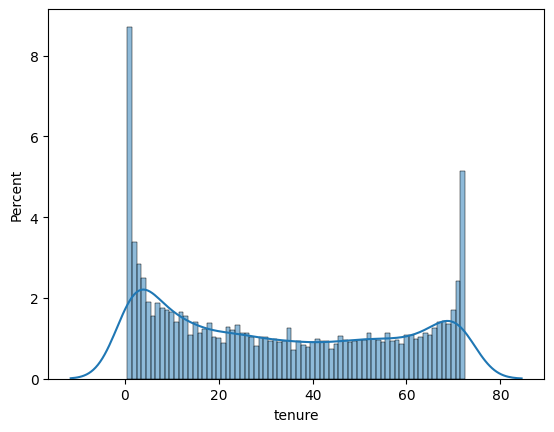

In [20]:
sns.histplot(df['tenure'], stat="percent", multiple="dodge", discrete=True, kde=True, kde_kws=dict(cut=3))

<Axes: xlabel='tenure'>

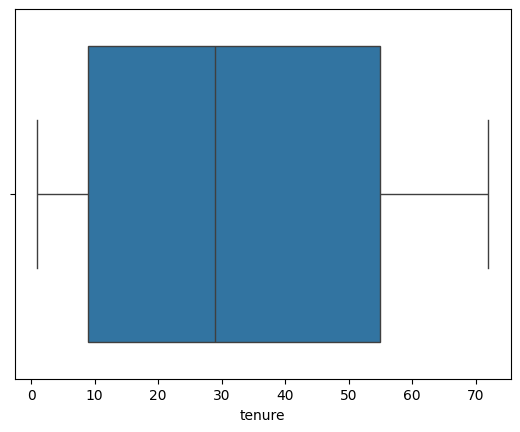

In [21]:
sns.boxplot(data=df, x='tenure')

**Conclusion**

*A large proportion of people are relatively new, while a smaller group has long-term tenure.*

Distribution suggests a large base of early-tenure customers and a smaller long-tenured segment.

<Axes: xlabel='MonthlyCharges', ylabel='Count'>

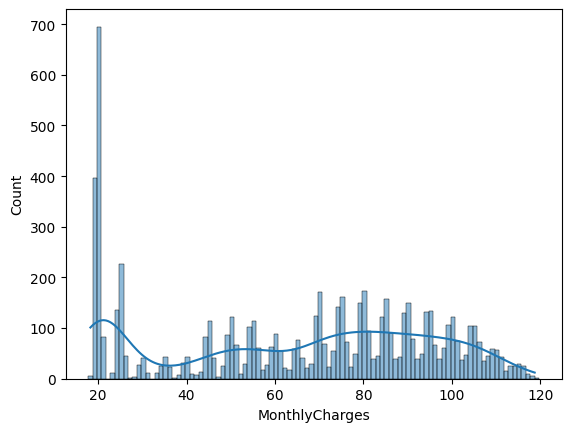

In [22]:
sns.histplot(df['MonthlyCharges'], discrete=True, kde=True)

<Axes: xlabel='MonthlyCharges'>

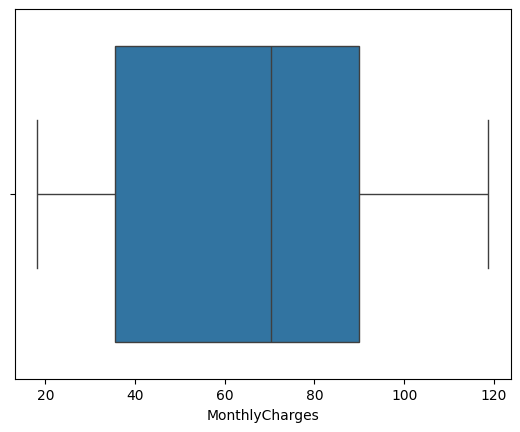

In [23]:
sns.boxplot(data=df, x='MonthlyCharges')

**Conclusion**

*There are peaks at $20 mark.*

<Axes: xlabel='TotalCharges', ylabel='Count'>

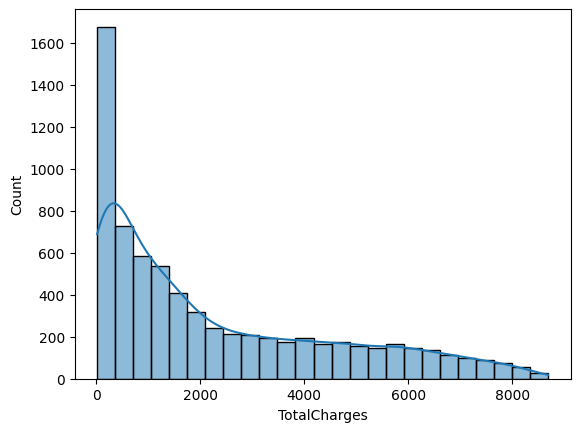

In [24]:
sns.histplot(df['TotalCharges'], kde=True)

<Axes: xlabel='TotalCharges'>

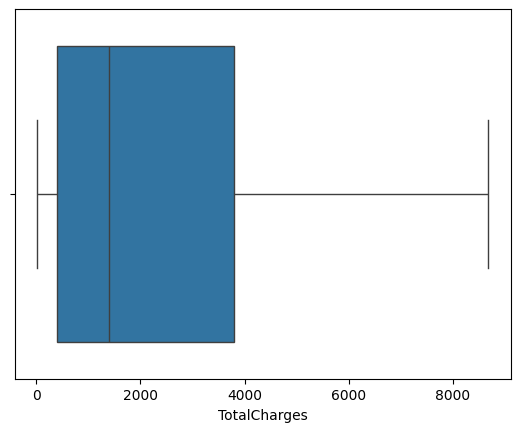

In [25]:
sns.boxplot(data=df, x='TotalCharges')

**Conclusions**

*Total charges are heavily right-skewed.*

***Right-skewed due to tenure accumulation... High spenders are few because long-tenured customers are fewer***

### **4. Bivariate Analysis (Feature vs Churn) >>>**

In [26]:
pd.crosstab(df['Contract'], df['Churn'], normalize='index')

Churn,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887228,0.112772
Two year,0.971513,0.028487


<Axes: xlabel='Contract'>

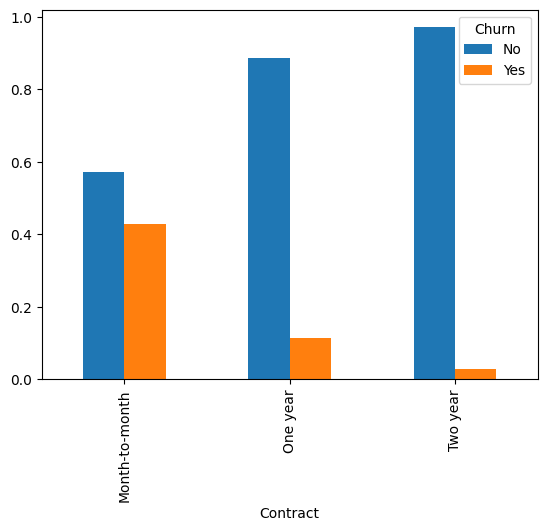

In [27]:
pd.crosstab(df['Contract'], df['Churn'], normalize='index').plot(kind='bar')

**Conclusion**

    Month-to-month → highest churn
    1–2 year contracts → lowest churn
***Month-to-month contract customers churn at a much higher rate.***

### **Cumulative Churn Risk over Time**

<Axes: xlabel='tenure', ylabel='Churn'>

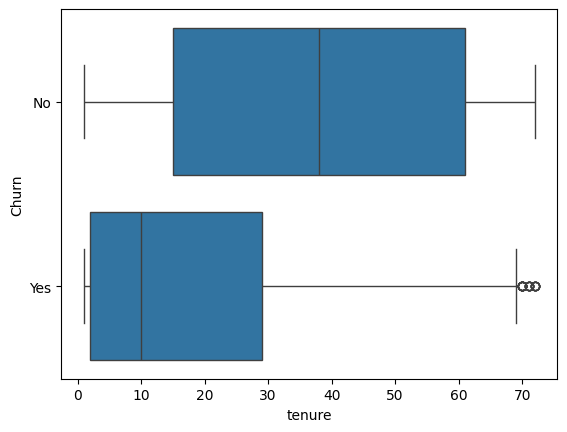

In [28]:
sns.boxplot(x='tenure', y='Churn', data=df)

**Conclusion**

    Low tenure → high churn
    Loyal customers stay longer
***The risk of churn is highest in the early stages of the customer lifecycle.***

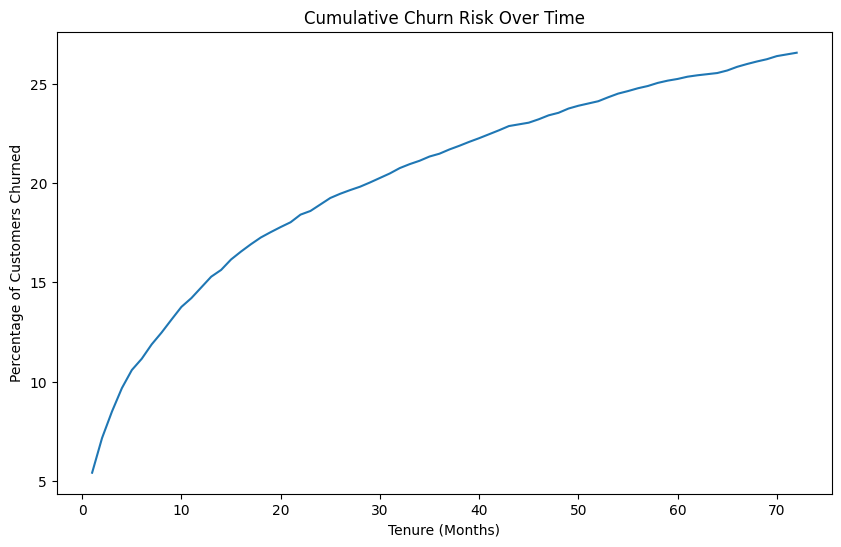

In [29]:
# 1. Filter for churned customers
churned = df[df['Churn'] == 'Yes']

# 2. Group by tenure and count
churn_by_tenure = churned.groupby('tenure').size().reset_index(name='count')

# 3. Calculate cumulative churn
churn_by_tenure['cumulative_churn'] = churn_by_tenure['count'].cumsum()

# 4. Calculate percentage of total initial customers (assuming all joined at t=0)
total_customers = len(df)
churn_by_tenure['cumulative_perc'] = (churn_by_tenure['cumulative_churn'] / total_customers) * 100

# 5. Plot
plt.figure(figsize=(10,6))
sns.lineplot(data=churn_by_tenure, x='tenure', y='cumulative_perc')
plt.title('Cumulative Churn Risk Over Time')
plt.ylabel('Percentage of Customers Churned')
plt.xlabel('Tenure (Months)')
plt.show()

<Axes: xlabel='MonthlyCharges', ylabel='Churn'>

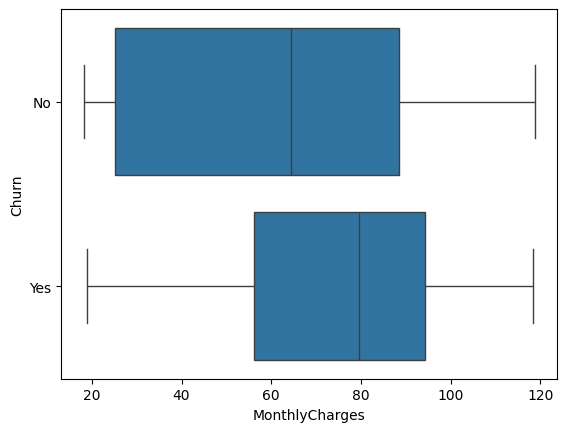

In [30]:
sns.boxplot(data=df, x='MonthlyCharges', y='Churn')

**Conclusion**

- Higher monthly charges → higher churn probability
- **Monthly charges increase churn only in the absence of contractual commitment.**

***Customers with higher monthly charges exhibit higher churn rates.***

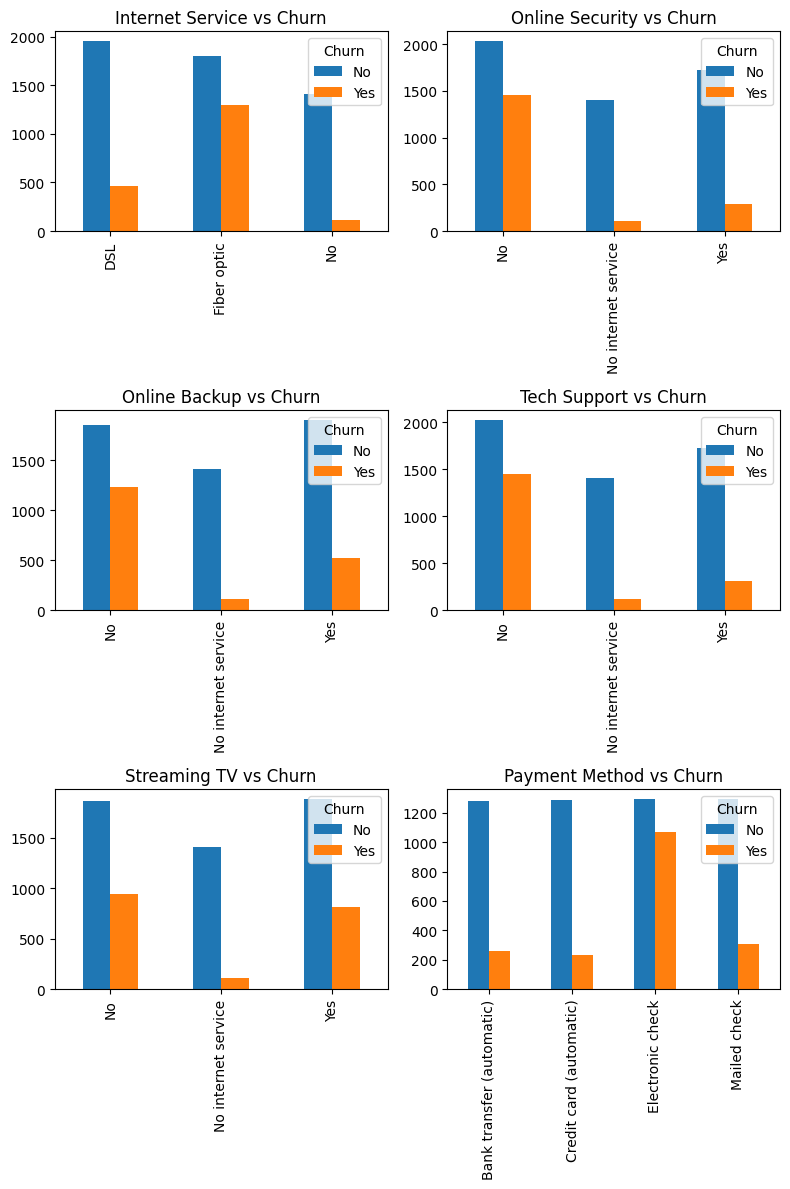

In [31]:
ct1 = pd.crosstab(df['InternetService'], df['Churn'])
ct2 = pd.crosstab(df['OnlineSecurity'], df['Churn'])
ct3 = pd.crosstab(df['OnlineBackup'], df['Churn'])
ct4 = pd.crosstab(df['TechSupport'], df['Churn'])
ct5 = pd.crosstab(df['StreamingTV'], df['Churn'])
ct6 = pd.crosstab(df['PaymentMethod'], df['Churn'])

fig = plt.figure(figsize=(8, 12))
gs = fig.add_gridspec(3, 2)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])
ax5 = fig.add_subplot(gs[2, 0])
ax6 = fig.add_subplot(gs[2, 1])


ct1.plot(kind='bar', ax=ax1, title='Internet Service vs Churn')
ct2.plot(kind='bar', ax=ax2, title='Online Security vs Churn')
ct3.plot(kind='bar', ax=ax3, title='Online Backup vs Churn')
ct4.plot(kind='bar', ax=ax4, title='Tech Support vs Churn')
ct5.plot(kind='bar', ax=ax5, title='Streaming TV vs Churn')
ct6.plot(kind='bar', ax=ax6, title='Payment Method vs Churn')

for ax in [ax1, ax2, ax3, ax4, ax5, ax6]:
    ax.set_xlabel('')
    ax.legend(title='Churn')

fig.tight_layout()
plt.show()

**Conclusion**

    Customers who do not use add-on services show higher churn compared to those who do.

***Customers with longer tenure are more likely to adopt add-on services, and these customers churn less.***

_**Churn rate by PaymentMethod:**
- Electronic check users churn the most
- Auto-pay users churn the least
- ***Automated payments correlate with higher retention.***

<Axes: xlabel='PaperlessBilling', ylabel='count'>

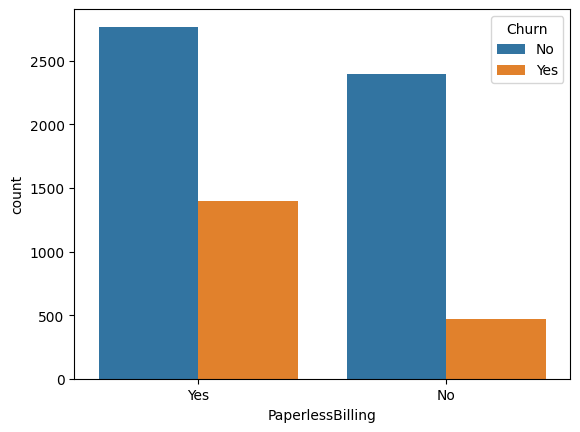

In [32]:
sns.countplot(data=df, x='PaperlessBilling', hue='Churn')

**Conclusion**

Customers with paperless billing show higher churn, likely due to overlap with short-term contracts and digital-only plans.

In [33]:
bins = [0, 6, 12, 24, df['tenure'].max()]
labels = ['0–6 months', '6–12 months', '1-2 years', '2+ years']

df['tenure_bucket'] = pd.cut(
    df['tenure'],
    bins=bins,
    labels=labels,
    right=False   # important
)

In [34]:
df['tenure_bucket'].value_counts().sort_index()

tenure_bucket
0–6 months     1360
6–12 months     698
1-2 years      1047
2+ years       3565
Name: count, dtype: int64

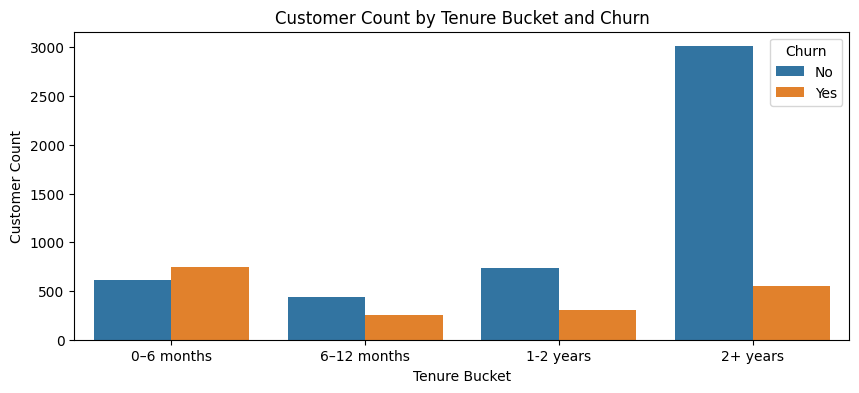

In [35]:
plt.figure(figsize=(10,4))
sns.countplot(
    data=df,
    x='tenure_bucket',
    hue='Churn'
)

plt.title('Customer Count by Tenure Bucket and Churn')
plt.xlabel('Tenure Bucket')
plt.ylabel('Customer Count')
plt.show()

**Conclusion**

Churn is disproportionately high in the first 6 months.

In [36]:
df['monthly_charge_bin'] = pd.qcut(
    df['MonthlyCharges'],
    q=5,
    duplicates='drop'
)

In [37]:
churn_rate = (
    df.groupby(['Contract', 'monthly_charge_bin'])['Churn']
        .apply(lambda x: (x == 'Yes').mean())
        .reset_index(name='churn_rate')
)

/tmp/ipykernel_162/2263436780.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['Contract', 'monthly_charge_bin'])['Churn']


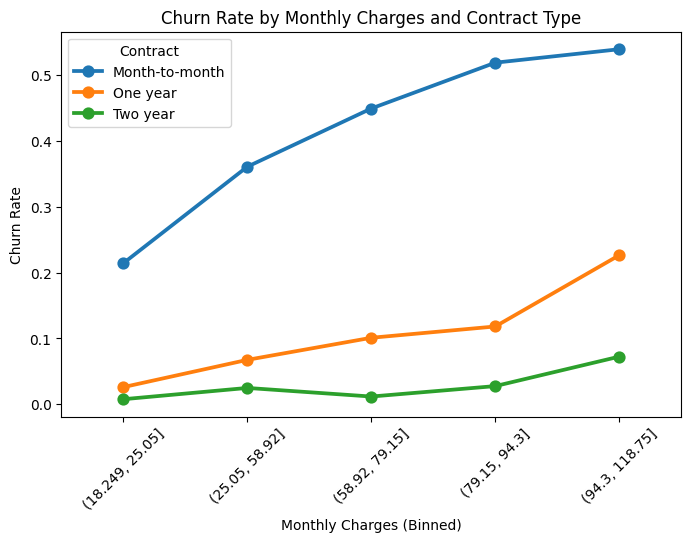

In [38]:
plt.figure(figsize=(8,5))
sns.pointplot(
    data=churn_rate,
    x='monthly_charge_bin',
    y='churn_rate',
    hue='Contract',
    markers='o'
)

plt.xticks(rotation=45)
plt.title('Churn Rate by Monthly Charges and Contract Type')
plt.xlabel('Monthly Charges (Binned)')
plt.ylabel('Churn Rate')
plt.show()

>High-charge, month-to-month customers are the highest-risk segment.

In [39]:
pivot_table = pd.pivot_table(df,
                             values=['MonthlyCharges', 'tenure'],
                             index='Contract',
                             columns='Churn',
                             aggfunc='mean')
print(pivot_table)

               MonthlyCharges                tenure           
Churn                      No        Yes         No        Yes
Contract                                                      
Month-to-month      61.462635  73.019396  21.033333  14.016918
One year            62.540926  85.050904  41.705972  44.963855
Two year            60.112798  86.777083  56.948687  61.270833


In [40]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

df[num_cols].corr()

,tenure,MonthlyCharges,TotalCharges
tenure,1.000000,0.246862,0.825880
MonthlyCharges,0.246862,1.000000,0.651065
TotalCharges,0.825880,0.651065,1.000000


#### **1. Tenure ↔ TotalCharges**

- Longer tenure → more months → more bills
- --> Of course TotalCharges go up

*Strong positive:- 0.826*


#### **2. tenure ↔ MonthlyCharges**

- --> MonthlyCharges = pricing plan
- --> tenure = how long customer stayed
- These are mostly independent.

*Weak or near zero:- 0.2479*

***People don’t stay longer just because price is high or low.***


#### **3. MonthlyCharges ↔ TotalCharges**

- --> TotalCharges ≈ MonthlyCharges × tenure
- So:

    High monthly cost
    Over many months
    --> Large total spend
    
*Moderate to strong positive:- 0.651*

***But not perfect, because tenure varies.***

## **Customer Value Segmentation**

In [41]:
# Ensure clean data
df = df.dropna(subset=['TotalCharges'])
df = df[df['tenure'] > 0]

In [42]:
def expected_remaining_tenure(t):
    if t < 6:
        return 6
    elif t < 12:
        return 12
    elif t < 24:
        return 18
    else:
        return 24

df['expected_remaining_tenure'] = df['tenure'].apply(expected_remaining_tenure)

In [43]:
df['heuristic_ltv'] = (
    df['MonthlyCharges'] * df['expected_remaining_tenure']
)

In [44]:
df['customer_value'] = pd.qcut(
    df['heuristic_ltv'],
    q=4,
    labels=['Low Value', 'Mid-Low Value', 'Mid-High Value', 'High Value']
)

In [45]:
df['customer_value'].value_counts()

customer_value
Mid-Low Value     1761
Low Value         1758
High Value        1757
Mid-High Value    1756
Name: count, dtype: int64

In [46]:
pd.crosstab(
    df['customer_value'],
    df['Churn'],
    normalize='index'
)

Churn,No,Yes
customer_value,,
Low Value,0.673493,0.326507
Mid-Low Value,0.720045,0.279955
Mid-High Value,0.768223,0.231777
High Value,0.775185,0.224815


/tmp/ipykernel_162/3749672182.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('customer_value')['Churn']


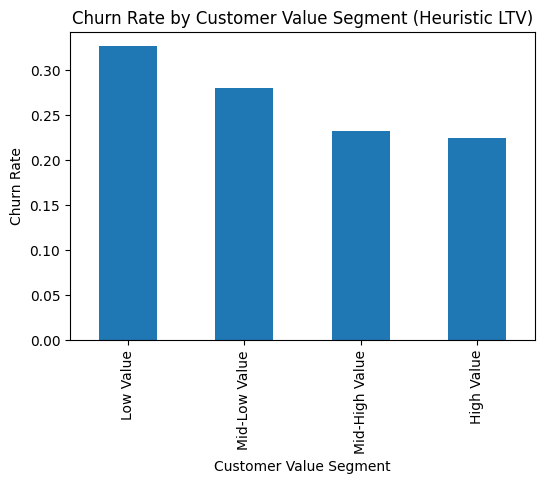

In [47]:
churn_by_value = (
    df.groupby('customer_value')['Churn']
      .apply(lambda x: (x == 'Yes').mean())
)

churn_by_value.plot(
    kind='bar',
    figsize=(6,4),
    title='Churn Rate by Customer Value Segment (Heuristic LTV)'
)

plt.ylabel('Churn Rate')
plt.xlabel('Customer Value Segment')
plt.show()

- Low-value customers churn more, while high-value customers are relatively stable.
> ***Churn risk is disproportionately higher among low-value customers, while high-value customers show strong retention.***

In [48]:
# Gender × Churn
pd.crosstab(
    df['gender'],
    df['Churn'],
    normalize='index'
)

Churn,No,Yes
gender,,
Female,0.730405,0.269595
Male,0.737954,0.262046


In [49]:
# Partner × Churn
pd.crosstab(
    df['Partner'],
    df['Churn'],
    normalize='index'
)

Churn,No,Yes
Partner,,
No,0.670239,0.329761
Yes,0.802829,0.197171


In [50]:
# Dependents × Churn
pd.crosstab(
    df['Dependents'],
    df['Churn'],
    normalize='index'
)

Churn,No,Yes
Dependents,,
No,0.687209,0.312791
Yes,0.844688,0.155312


In [51]:
def churn_rate_plot(df, col):
    churn_rate = (
        df.groupby(col)['Churn']
          .apply(lambda x: (x == 'Yes').mean())
    )
    
    churn_rate.plot(
        kind='bar',
        figsize=(4,3),
        title=f'Churn Rate by {col}'
    )
    
    plt.ylabel('Churn Rate')
    plt.xlabel(col)
    plt.ylim(0, churn_rate.max() + 0.05)
    plt.show()


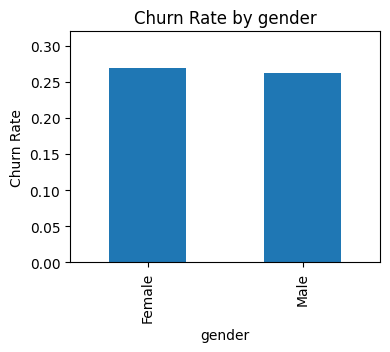

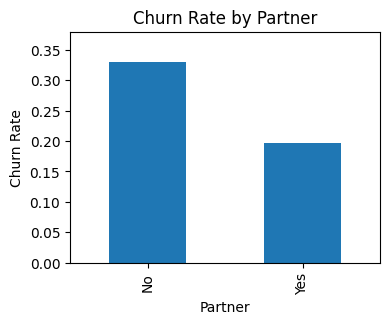

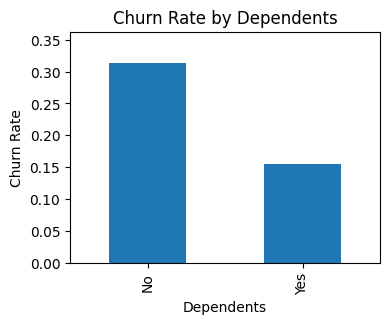

In [52]:
churn_rate_plot(df, 'gender')
churn_rate_plot(df, 'Partner')
churn_rate_plot(df, 'Dependents')


> **Gender** has negligible impact on churn.

> **Partnered customers** show lower churn, suggesting household-level stickiness.

> Customers with **dependents** exhibit significantly lower churn, likely due to higher switching costs and service reliance.

----------
# **EDA Summary**
----------
**Overall Churn**
- About 26.5% of customers have churned, which shows that customer retention is a serious business issue.

**Customer Base Overview**
- Most customers are on month-to-month contracts, with fewer customers committed to one-year or two-year contracts.
- Electronic check is the most commonly used payment method, while automatic payment methods are less common.

**Data Distribution (Numerical Features)**
- Tenure and total charges are right-skewed, meaning many customers are relatively new and only a smaller group has stayed for a long time.
- Monthly charges vary widely, showing that customers are on different pricing plans.

**Contract Type and Churn**
- Customers on month-to-month contracts churn much more than those on longer contracts.
- Longer contracts are linked with better customer retention.

**Tenure and Churn**
- Customers who churn usually have shorter tenure.
- The highest churn happens in the early months, making the initial customer period very important.

**Monthly Charges and Churn**
- Customers with higher monthly charges churn more than customers with lower charges.
- High pricing combined with short tenure increases churn risk.

**Payment Method and Churn**
- Customers who pay using electronic check churn more than those using automatic payment methods.
- Automatic payments are linked with lower churn.

**Paperless Billing and Churn**
- Customers using paperless billing show higher churn, likely because this group overlaps with short-term or price-sensitive customers.

**Services and Churn**
- Customers who do not use add-on services like online security or tech support churn more.
- Using additional services helps keep customers longer.

**Customer Value Insight**
- New and low-value customers churn more often, while long-term, high-value customers are more stable.
- Retention efforts should focus on early-stage customers who still have the potential to stay longer.
----------

### ***Churn risk is highest among early-tenure, month-to-month customers with higher monthly charges, electronic check payment methods, paperless billing, and limited use of value-added services.***

### **These customers represent the most actionable segment for targeted retention strategies such as contract incentives, onboarding improvements, service bundling, and payment automation.**


## **Binary Encoding**

In [53]:
binary_cols = [
    'gender', 'Partner', 'Dependents',
    'PhoneService', 'PaperlessBilling', 'Churn'
]

binary_map = {
    'Yes': 1,
    'No': 0,
    'Male': 1,
    'Female': 0
}

for col in binary_cols:
    df[col] = df[col].map(binary_map)

## **One-hot encoding**

In [54]:
one_hot_cols = [
    'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies'
]

df = pd.get_dummies(df, columns=one_hot_cols, drop_first=True)

In [55]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,InternetService,Contract,PaperlessBilling,PaymentMethod,...,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes
0,0,0,1,0,1,0,DSL,Month-to-month,1,Electronic check,...,False,True,False,False,False,False,False,False,False,False
1,1,0,0,0,34,1,DSL,One year,0,Mailed check,...,False,False,False,True,False,False,False,False,False,False
2,1,0,0,0,2,1,DSL,Month-to-month,1,Mailed check,...,False,True,False,False,False,False,False,False,False,False
3,1,0,0,0,45,0,DSL,One year,0,Bank transfer (automatic),...,False,False,False,True,False,True,False,False,False,False
4,0,0,0,0,2,1,Fiber optic,Month-to-month,1,Electronic check,...,False,False,False,False,False,False,False,False,False,False


In [56]:
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

In [57]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,InternetService,Contract,PaperlessBilling,PaymentMethod,...,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes
0,0,0,1,0,1,0,DSL,Month-to-month,1,Electronic check,...,0,1,0,0,0,0,0,0,0,0
1,1,0,0,0,34,1,DSL,One year,0,Mailed check,...,0,0,0,1,0,0,0,0,0,0
2,1,0,0,0,2,1,DSL,Month-to-month,1,Mailed check,...,0,1,0,0,0,0,0,0,0,0
3,1,0,0,0,45,0,DSL,One year,0,Bank transfer (automatic),...,0,0,0,1,0,1,0,0,0,0
4,0,0,0,0,2,1,Fiber optic,Month-to-month,1,Electronic check,...,0,0,0,0,0,0,0,0,0,0


In [58]:
df = pd.get_dummies(
    df,
    columns=['InternetService', 'Contract'],
    drop_first=True
)

In [59]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,...,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year
0,0,0,1,0,1,0,1,Electronic check,29.85,29.85,...,0,0,0,0,0,0,False,False,False,False
1,1,0,0,0,34,1,0,Mailed check,56.95,1889.50,...,0,0,0,0,0,0,False,False,True,False
2,1,0,0,0,2,1,1,Mailed check,53.85,108.15,...,0,0,0,0,0,0,False,False,False,False
3,1,0,0,0,45,0,0,Bank transfer (automatic),42.30,1840.75,...,0,1,0,0,0,0,False,False,True,False
4,0,0,0,0,2,1,1,Electronic check,70.70,151.65,...,0,0,0,0,0,0,True,False,False,False


In [60]:
pd.set_option('display.max_columns', None)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_bucket,monthly_charge_bin,expected_remaining_tenure,heuristic_ltv,customer_value,MultipleLines_No phone service,MultipleLines_Yes,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year
0,0,0,1,0,1,0,1,Electronic check,29.85,29.85,0,0–6 months,"(25.05, 58.92]",6,179.1,Low Value,1,0,0,0,0,1,0,0,0,0,0,0,0,0,False,False,False,False
1,1,0,0,0,34,1,0,Mailed check,56.95,1889.50,0,2+ years,"(25.05, 58.92]",24,1366.8,Mid-High Value,0,0,0,1,0,0,0,1,0,0,0,0,0,0,False,False,True,False
2,1,0,0,0,2,1,1,Mailed check,53.85,108.15,1,0–6 months,"(25.05, 58.92]",6,323.1,Low Value,0,0,0,1,0,1,0,0,0,0,0,0,0,0,False,False,False,False
3,1,0,0,0,45,0,0,Bank transfer (automatic),42.30,1840.75,0,2+ years,"(25.05, 58.92]",24,1015.2,Mid-Low Value,1,0,0,1,0,0,0,1,0,1,0,0,0,0,False,False,True,False
4,0,0,0,0,2,1,1,Electronic check,70.70,151.65,1,0–6 months,"(58.92, 79.15]",6,424.2,Low Value,0,0,0,0,0,0,0,0,0,0,0,0,0,0,True,False,False,False


In [61]:
df = pd.get_dummies(
    df,
    columns=['PaymentMethod'],
    drop_first=True
)

In [62]:
df_model = df.drop(columns=['customer_value'])

In [63]:
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

In [64]:
pd.set_option('display.max_columns', None)
# pd.set_option('display.max_rows', None)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,tenure_bucket,monthly_charge_bin,expected_remaining_tenure,heuristic_ltv,customer_value,MultipleLines_No phone service,MultipleLines_Yes,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,0–6 months,"(25.05, 58.92]",6,179.1,Low Value,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,2+ years,"(25.05, 58.92]",24,1366.8,Mid-High Value,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1
2,1,0,0,0,2,1,1,53.85,108.15,1,0–6 months,"(25.05, 58.92]",6,323.1,Low Value,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,45,0,0,42.30,1840.75,0,2+ years,"(25.05, 58.92]",24,1015.2,Mid-Low Value,1,0,0,1,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0
4,0,0,0,0,2,1,1,70.70,151.65,1,0–6 months,"(58.92, 79.15]",6,424.2,Low Value,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0


In [65]:
(df['Churn'] == 1).mean()

np.float64(0.26578498293515357)

In [66]:
pd.crosstab(df['Contract_One year'], df['Churn'], normalize='index')

Churn,0,1
Contract_One year,,
0,0.693705,0.306295
1,0.887228,0.112772


## **Pandas Profiling**

In [67]:
from ydata_profiling import ProfileReport
prof = ProfileReport(df, explorative=True)
prof.to_file('output.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 36/36 [00:00<00:00, 43.42it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

<ins><p style="font-family: 'Times New Roman', serif; font-size: 35px; font-weight: bold; text-decoration: underline;"> 
    [5] EDA Validation
</p></ins>

## **Multivariate Thinking**

In [68]:
df_model = df.copy()

X = df_model[[
    'tenure',
    'MonthlyCharges',
    'PaperlessBilling',
    'Contract_One year',
    'Contract_Two year',
    'InternetService_Fiber optic',
    'PaymentMethod_Electronic check',
    'PaymentMethod_Credit card (automatic)',
    'PaymentMethod_Mailed check'
]]

y = df_model['Churn']

In [69]:
X.isnull().sum()

tenure                                   0
MonthlyCharges                           0
PaperlessBilling                         0
Contract_One year                        0
Contract_Two year                        0
InternetService_Fiber optic              0
PaymentMethod_Electronic check           0
PaymentMethod_Credit card (automatic)    0
PaymentMethod_Mailed check               0
dtype: int64

In [70]:
X.dtypes

tenure                                     int64
MonthlyCharges                           float64
PaperlessBilling                           int64
Contract_One year                          int64
Contract_Two year                          int64
InternetService_Fiber optic                int64
PaymentMethod_Electronic check             int64
PaymentMethod_Credit card (automatic)      int64
PaymentMethod_Mailed check                 int64
dtype: object

>Compare customers who are same in every way, except ONE thing — and see what still matters.

In [71]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X, y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [72]:
coef_df = (
    pd.DataFrame({
        'Feature': X.columns,
        'Coefficient': lr.coef_[0]
    })
    .sort_values(by='Coefficient', ascending=False)
)

coef_df

,Feature,Coefficient
5,InternetService_Fiber optic,0.679888
2,PaperlessBilling,0.439699
6,PaymentMethod_Electronic check,0.436660
1,MonthlyCharges,0.012504
0,tenure,-0.033932
7,PaymentMethod_Credit card (automatic),-0.083620
8,PaymentMethod_Mailed check,-0.098868
3,Contract_One year,-0.814302
4,Contract_Two year,-1.597417


In [73]:
coef_df['Odds_Ratio'] = np.exp(coef_df['Coefficient'])
coef_df

,Feature,Coefficient,Odds_Ratio
5,InternetService_Fiber optic,0.679888,1.973657
2,PaperlessBilling,0.439699,1.552239
6,PaymentMethod_Electronic check,0.436660,1.547529
1,MonthlyCharges,0.012504,1.012582
0,tenure,-0.033932,0.966638
7,PaymentMethod_Credit card (automatic),-0.083620,0.919781
8,PaymentMethod_Mailed check,-0.098868,0.905863
3,Contract_One year,-0.814302,0.442949
4,Contract_Two year,-1.597417,0.202419


* Contract length, tenure, and fiber optic service remained strong churn drivers even after controls.
* Monthly charges stayed directionally positive but weakened significantly, indicating pricing effects are contextual rather than primary.
* This confirmed that the EDA insights were largely robust but also corrected where univariate analysis overstated effects.

## **Size x Risk x Value**

In [74]:
df['TenureBucket'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=['0–12', '13–24', '25–48', '49+']
)

In [75]:
df['ChargeLevel'] = pd.qcut(
    df['MonthlyCharges'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

In [76]:
df['Contract_Rebuilt'] = 'Month-to-month'

df.loc[df['Contract_One year'] == 1, 'Contract_Rebuilt'] = 'One year'
df.loc[df['Contract_Two year'] == 1, 'Contract_Rebuilt'] = 'Two year'

In [77]:
df['InternetService_Rebuilt'] = 'DSL'
df.loc[df['InternetService_Fiber optic'] == 1, 'InternetService_Rebuilt'] = 'Fiber optic'

In [78]:
segment_1 = (
    df.groupby(['Contract_Rebuilt', 'InternetService_Rebuilt'])
      .agg(
          Customers=('Churn', 'size'),
          ChurnRate=('Churn', 'mean'),
          AvgRevenue=('MonthlyCharges', 'mean')
      )
      .reset_index()
)

In [79]:
segment_2 = (
    df.groupby(['TenureBucket', 'ChargeLevel'])
      .agg(
          Customers=('Churn', 'size'),
          ChurnRate=('Churn', 'mean'),
          AvgRevenue=('MonthlyCharges', 'mean')
      )
      .reset_index()
)

/tmp/ipykernel_162/4051678383.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['TenureBucket', 'ChargeLevel'])


In [80]:
for seg in [segment_1, segment_2]:
    seg['RiskValueScore'] = (
        seg['Customers'] *
        seg['ChurnRate'] *
        seg['AvgRevenue']
    )

In [81]:
segment_1_sorted = segment_1.sort_values(
    'RiskValueScore', ascending=False
)

In [82]:
segment_2_sorted = segment_2.sort_values(
    'RiskValueScore', ascending=False
)

In [83]:
segment_1_sorted

,Contract_Rebuilt,InternetService_Rebuilt,Customers,ChurnRate,AvgRevenue,RiskValueScore
1,Month-to-month,Fiber optic,2128,0.546053,87.021194,101118.626974
0,Month-to-month,DSL,1747,0.282198,41.278220,20350.162364
3,One year,Fiber optic,539,0.192950,98.779499,10273.067904
5,Two year,Fiber optic,429,0.072261,104.571445,3241.714802
2,One year,DSL,933,0.066452,45.610665,2827.861200
4,Two year,DSL,1256,0.013535,45.946497,781.090446


### **Segment 1**
**Month-to-month + Fiber optic**
- Customers: 2128 (very large)]
- Churn rate: 54.6% (more than half leave)
- Avg revenue: ₹87
- RiskValueScore: ~101,119 (HIGHEST)

*This group is huge, bleeds customers, and pays a lot.*

*If the company fixes ONLY ONE segment — it must be this one.*

### **Segment 2**
**Month-to-month + DSL**
- Customers: 1747
- Churn rate: 28%
- Avg revenue: ₹41
- RiskValueScore: ~20,350

*Large group, moderate churn, lower value.*

*Important, but far less dangerous than fiber + month-to-month.*

### **Segment 3**
**One-year + Fiber optic**
- Customers: 539
- Churn rate: 19%
- Avg revenue: ₹99
- RiskValueScore: ~10,273

*Fiber is risky, but contract reduces damage.*

In [84]:
segment_2_sorted

,TenureBucket,ChargeLevel,Customers,ChurnRate,AvgRevenue,RiskValueScore
1,0–12,Medium,857,0.543757,69.572404,32420.740140
2,0–12,High,375,0.738667,92.438400,25605.436800
8,25–48,High,580,0.351724,96.581121,19702.548621
11,49+,High,1093,0.151876,100.420037,16669.726075
5,13–24,High,294,0.513605,93.757313,14157.354252
0,0–12,Low,943,0.311771,29.571792,8694.106893
4,13–24,Medium,369,0.284553,68.558130,7198.603659
7,25–48,Medium,522,0.180077,68.397318,6429.347893
10,49+,Medium,597,0.055276,69.280653,2286.261558
3,13–24,Low,361,0.105263,27.610111,1049.184211


### **Segment 1**
**Tenure 0–12 months + Medium charges**
- Customers: 857
- Churn rate: 54%
- Avg revenue: ₹69
- RiskValueScore: ~32,421

*New customers with medium bills are extremely risky.*

### **Segment 2**
**Tenure 0–12 months + High charges**
- Customers: 375
- Churn rate: 74% (very high)
- Avg revenue: ₹92
- RiskValueScore: ~25,605

*New + expensive customers leave FAST.*

### **Segment 3**
**Tenure 25–48 months + High charges**
- Customers: 580
- Churn rate: 35%
- Avg revenue: ₹96

*Even older customers churn if bills are high.*

<ins><p style="font-family: 'Times New Roman', serif; font-size: 22px; font-weight: bold;">
    Using a Size × Risk × Value framework, we found that churn risk is highly concentrated in month-to-month fiber customers, especially within the first year. These segments combine high customer volume, high churn rates, and high revenue exposure, making them the top priorities for retention efforts.
</p></ins>

In [85]:
# Segment-wise Size x Risk x Value (Step 2 output)
segments = pd.DataFrame({
    'Segment': [
        'Month-to-month + Fiber', 'Month-to-month + DSL', 'One-year + Fiber',
        'Two-year + Fiber', 'One-year + DSL', 'Two-year + DSL'
    ],
    'Customers': [2128, 1747, 539, 429, 933, 1256],
    'ChurnRate': [0.546053, 0.282198, 0.192950, 0.072261, 0.066452, 0.013535],
    'AvgRevenue': [87.021194, 41.278220, 98.779499, 104.571445, 45.610665, 45.946497],
    'RiskValueScore': [101118.626974, 20350.162364, 10273.067904, 3241.714802, 2827.861200, 781.090446]
})

In [86]:
# Hypothetical intervention assumptions
top_percent_target = 0.10      # targeting top 10% risky customers
churn_reduction = 0.05         # intervention reduces churn by 5%
avg_monthly_charge = 70        # assumed average monthly charge
avg_remaining_tenure = 6       # months

In [87]:
# Step 3 calculation
segments['TargetedCustomers'] = (segments['Customers'] * top_percent_target).astype(int)
segments['CustomersSaved'] = (segments['TargetedCustomers'] * churn_reduction).astype(int)
segments['RevenueSaved'] = segments['CustomersSaved'] * avg_monthly_charge * avg_remaining_tenure

# Compute Lift: Churn rate of segment / Overall churn (assume overall churn = 0.265)
overall_churn = 0.265
segments['Lift'] = segments['ChurnRate'] / overall_churn

segments

,Segment,Customers,ChurnRate,AvgRevenue,RiskValueScore,TargetedCustomers,CustomersSaved,RevenueSaved,Lift
0,Month-to-month + Fiber,2128,0.546053,87.021194,101118.626974,212,10,4200,2.060577
1,Month-to-month + DSL,1747,0.282198,41.278220,20350.162364,174,8,3360,1.064898
2,One-year + Fiber,539,0.192950,98.779499,10273.067904,53,2,840,0.728113
3,Two-year + Fiber,429,0.072261,104.571445,3241.714802,42,2,840,0.272683
4,One-year + DSL,933,0.066452,45.610665,2827.861200,93,4,1680,0.250762
5,Two-year + DSL,1256,0.013535,45.946497,781.090446,125,6,2520,0.051075


### **Segment 1: Month-to-month + Fiber**
- Lift: 2.06 (very high risk)
- Customers saved: 10
- Revenue saved: ₹4,200

*High risk, high value, best ROI for intervention.*

> ***TOP PRIORITY***

### **Segment 2: Month-to-month + DSL**
- Lift: ~1.06 (slightly above average)
- Customers saved: 8
- Revenue saved: ₹3,360

*Worth targeting, but not as critical.*

### **Segment 3: One-year + Fiber**
- Lift < 1
- Lower incremental saves

*Medium priority, secondary campaigns only.*


<ins><p style="font-family: 'Times New Roman', serif; font-size: 22px; font-weight: bold;">
    After identifying high-risk segments, I estimated business impact using lift and incremental saves. By assuming realistic targeting and intervention effectiveness, I showed that month-to-month fiber customers have over 2× churn risk and deliver the highest incremental revenue retention per campaign.
</p></ins>

___
## EDA Summary (Frozen)

Key observations:
- Month-to-month customers show significantly higher churn than contract customers.
- Fiber optic service users exhibit higher churn across tenure bands.
- Short-tenure customers churn more frequently than long-tenure customers.
- Monthly charges are positively associated with churn but appear contextual.

EDA is considered complete and stable.
___

### EDA Validation Result

Directional results from logistic regression align with EDA findings:
- Contract length and tenure reduce churn risk.
- Fiber optic service remains a high-risk segment after controls.
- Monthly charges show a weaker but positive association with churn.

This model is used strictly for validation, not prediction.
___

### Segment Prioritization (Size × Risk × Value)

Customer segments were prioritized based on:
- Number of customers
- Churn risk
- Revenue exposure

Highest-risk segments:
1. Month-to-month + Fiber optic
2. Month-to-month + DSL
3. New customers (0–12 months) with high charges
___

## Business Recommendations

- Focus retention initiatives on month-to-month fiber optic customers.
- Incentivize migration from month-to-month to annual contracts.
- Prioritize high-value, high-risk segments to maximize ROI.
- Avoid blanket discounts on low-risk, long-tenure customers
___